<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundation/45_confusion_matrix_and_classification_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

predictions = rf.predict(
    X_test
)

In [5]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[48  2]
 [ 6 44]]


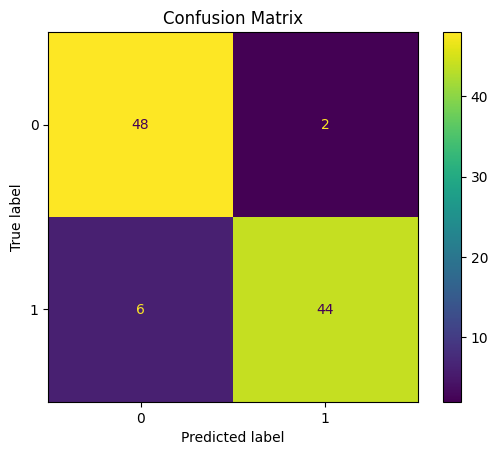

In [6]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Confusion Matrix"
)

plt.show()

In [7]:
report = classification_report(
    y_test,
    predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        50
           1       0.96      0.88      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



In [8]:
report_dict = classification_report(
    y_test,
    predictions,
    output_dict=True
)

report_df = pd.DataFrame(
    report_dict
).transpose()

report_df

,precision,recall,f1-score,support
0,0.888889,0.96,0.923077,50.00
1,0.956522,0.88,0.916667,50.00
accuracy,0.920000,0.92,0.920000,0.92
macro avg,0.922705,0.92,0.919872,100.00
weighted avg,0.922705,0.92,0.919872,100.00


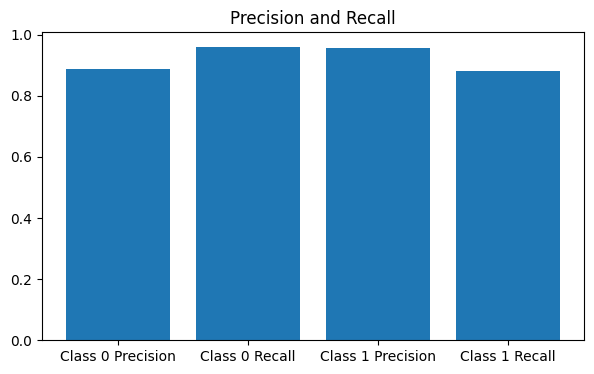

In [9]:
metrics_df = report_df.iloc[:2]

plt.figure(figsize=(7,4))

plt.bar(
    ["Class 0 Precision",
     "Class 0 Recall",
     "Class 1 Precision",
     "Class 1 Recall"],

    [
        metrics_df.iloc[0]["precision"],
        metrics_df.iloc[0]["recall"],
        metrics_df.iloc[1]["precision"],
        metrics_df.iloc[1]["recall"]
    ]
)

plt.title(
    "Precision and Recall"
)

plt.show()

## Conclusion

The Confusion Matrix and Classification Report provide deeper insights into model performance than accuracy alone.

Observations:
- Precision measures prediction correctness.
- Recall measures detection capability.
- F1 Score balances precision and recall.
- Confusion Matrix shows detailed prediction outcomes.